In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import struct

sns.set_theme()

In [6]:
data_dir = "/home/patrick/Projects/DataScienceAndMachineLearning/Data/"

train_labels_path = data_dir + "MNIST-Dataset/train-labels.idx1-ubyte"
train_images_path = data_dir + "MNIST-Dataset/train-images.idx3-ubyte"
test_labels_path = data_dir + "MNIST-Dataset/t10k-labels.idx1-ubyte"
test_images_path = data_dir + "MNIST-Dataset/t10k-images.idx3-ubyte"

def read_labels(labels_path):
    with open(labels_path, "rb") as file:
        magic, size = struct.unpack(">II", file.read(8))
        labels = np.frombuffer(file.read(), dtype=np.uint8)
    return labels

def read_images(images_path):
    with open(images_path, "rb") as file:
        magic, size, rows, cols = struct.unpack(">IIII", file.read(16))
        image_data = np.frombuffer(file.read(), dtype=np.uint8)
        final_image_data = np.empty((size, rows, cols), dtype=np.uint8)
        for i in range(size):
            img = image_data[i*rows*cols:(i+1)*rows*cols].reshape(rows, cols)
            final_image_data[i, :, :] = img
        return final_image_data
train_labels = read_labels(train_labels_path)
train_images = read_images(train_images_path)
test_labels = read_labels(test_labels_path)
test_images = read_images(test_images_path)

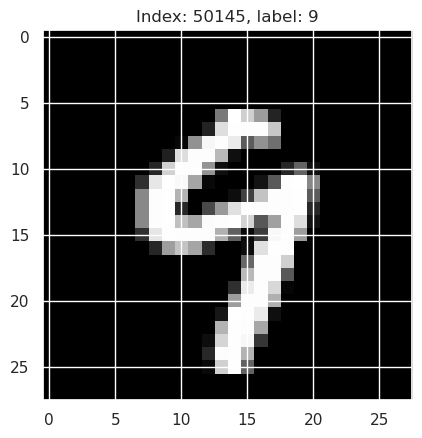

In [7]:
def show_image(images, labels, index):
    plt.imshow(images[index, :, :], cmap=plt.cm.gray)
    plt.title(f"Index: {index}, label: {labels[index]}")
    plt.show()

show_image(train_images, train_labels, 50145)

In [157]:
X = train_images / 255.0
y = np.zeros((len(train_labels), 10))
for i in range(len(train_labels)):
    label = train_labels[i]
    y[i, label] = 1.0

In [158]:
def sigmoid(x):
    return 1/(1 + np.exp(-x))

def derivative_sigmoid(x):
    return sigmoid(x) * (1-sigmoid(x))

In [191]:
class MultilayerPerceptron():
    def __init__(self, _layer_counts, _activation_function, _activation_function_derivative):
        # layer_counts is a list of the number of neurons to place in each hidden layer. The length
        # of layer_counts indicates how many hidden layers there are.
        self.layer_counts = _layer_counts
        self.activation_function = _activation_function
        self.activation_function_derivative = _activation_function_derivative

    def train(self, X, y, possible_outputs, eta = 0.1, epochs = 1000):
        # first extract dimensional information
        self.dim = X.shape[0]
        self.rows, self.cols = X.shape[1], X.shape[2]
        self.weights = [] # list of np matrices
        self.bias = [] # list of np arrays

        # first layer neurons are just the values of the image, no neurons necessary

        all_layer_counts = [self.rows*self.cols]
        all_layer_counts.extend(self.layer_counts)
        all_layer_counts.append(possible_outputs)
        
        activations = []
        z_vals = []
        error_vals = []

        self.n = len(all_layer_counts)
        batch_size = 100 # set batch size to be a divisor of the training data length

        for i in range(self.n-1):
            # create neuron layer
            num_weights_per_neuron = all_layer_counts[i]
            num_neurons = all_layer_counts[i+1]
            self.weights.append(np.random.rand(num_weights_per_neuron, num_neurons)*1/num_weights_per_neuron)
            self.bias.append(np.random.rand(num_neurons, 1)*1/num_weights_per_neuron)
        for i in range(self.n):
            z_vals.append(np.empty((batch_size, all_layer_counts[i])))
            activations.append(np.empty((batch_size, all_layer_counts[i])))
            error_vals.append(np.empty((batch_size, all_layer_counts[i])))
        
        # what to code here?
        # first off: feedforward
        # then: backprop for a sample of the dataset
        current_loc = 0
        
        i = 0
        while i < epochs:
            X_batch = X[current_loc:current_loc+batch_size, :, :].reshape(batch_size, -1) # batch size by rows*cols matrix
            y_batch = y[current_loc:current_loc+batch_size, :] # batch size by possible_outputs matrix
            current_loc += batch_size
            if current_loc >= self.dim:
                current_loc = 0
            activations[0] = X_batch
            # contains a_L
            for j in range(self.n-1):
                z_val = np.dot(self.weights[j].T, activations[j].T).T + self.bias[j].T
                activation = self.activation_function(z_val)
                z_vals[j+1] = z_val
                activations[j+1] = activation
            grad_C = 1/batch_size * (activations[-1] - y_batch) # dimension batch_size by possible_outputs
            z_deriv = self.activation_function_derivative(z_vals[-1])
            error_vals[-1] = grad_C * z_deriv # needs to be batch_size by possible_outputs
            for j in range(self.n-2, 0, -1):
                error_leftside = np.dot(self.weights[j], error_vals[j+1].T).T
                error_val = error_leftside * self.activation_function_derivative(z_vals[j])
                error_vals[j] = error_val
            for j in range(self.n-1, 0, -1):
                self.weights[j-1] = self.weights[j-1] - eta*np.dot(error_vals[j].T, (activations[j-1])).T
                
                # print(np.shape(self.bias[j-1]))
                # print(np.shape(eta*np.sum(error_vals[j].T, axis=1, keepdims=True)))
                self.bias[j-1] = self.bias[j-1] - eta*np.sum(error_vals[j].T, axis=1, keepdims=True)
                # print(np.shape(self.bias[j-1]))
            # print(self.cost(y_batch, activations[n-1]))
            i += 1
            if i % 100 == 0:
                print(self.cost(y_batch, activations[-1]))
                print(activations[-1][0])
                print(y_batch[0])
                print("-----")
        # how to store weights? should probably just store neuron objects

    def cost(self, y, y_hats):
        return 1/(2*self.dim) * np.sum((y-y_hats)**2, axis=0)

    def feed_forward(self, X):
        activation = X
        for j in range(self.n-1):
            z_val = np.dot(self.weights[j].T, activation.T).T + self.bias[j].T
            activation = self.activation_function(z_val)
        return activation

    # once we have batch set: compute the feed forward to get the diffs

In [193]:
nn = MultilayerPerceptron([16, 16], sigmoid, derivative_sigmoid)
errors = nn.train(X, y, 10, eta = 0.5, epochs=10000)

[8.84378606e-05 8.76959923e-05 6.18002942e-05 7.50765147e-05
 6.14469400e-05 4.76280000e-05 8.16419139e-05 8.15645241e-05
 1.02157288e-04 6.15429017e-05]
[0.10084814 0.10997458 0.10128172 0.10529251 0.09109385 0.08661604
 0.10156745 0.10461812 0.09429271 0.09494102]
[0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
-----
[8.84154379e-05 7.48317087e-05 5.48043963e-05 6.84693222e-05
 8.17256419e-05 8.87988180e-05 8.84714895e-05 5.49298570e-05
 6.84962570e-05 8.16592614e-05]
[0.09783646 0.11501291 0.09178351 0.10043147 0.09412756 0.08848168
 0.09352822 0.09887119 0.09507375 0.10086779]
[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
-----
[6.84307864e-05 1.00590701e-04 5.49985483e-05 5.48787260e-05
 6.84487317e-05 5.47565631e-05 7.50720694e-05 1.08204627e-04
 6.16476041e-05 1.01647080e-04]
[0.10049132 0.11328531 0.10115073 0.09710457 0.09855353 0.09570005
 0.10208028 0.10180524 0.09739294 0.10092141]
[0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
-----
[6.85327019e-05 8.75701085e-05 7.49842412e-05 7.49978518e-05
 5.50687932e-05 1.298825

In [190]:
# now test! prep test data
X_test = test_images / 255.0
y_test = np.zeros((len(test_labels), 10))
for i in range(len(test_labels)):
    label = test_labels[i]
    y_test[i, label] = 1.0
# for i in range(nn.n):
#     print(np.shape(nn.bias[i]))
y_hat_test = nn.feed_forward(X_test.reshape(10000, -1))
results = nn.cost(y_test, y_hat_test)
print(y_test[1])
print(y_hat_test[1])
print(results)
sum_results = np.sum(results, axis=0)
# print(sum_results)

[0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
[0.09736256 0.1152041  0.09952519 0.10100718 0.09814259 0.09094802
 0.09974062 0.10268297 0.09729809 0.10037232]
[0.00738878 0.0083246  0.00771861 0.00757388 0.00737881 0.00677411
 0.00722892 0.00767258 0.00734354 0.00756354]
